In [1]:
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import re

import torch
from torch import cuda
from torch.utils.data import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support


# from transformers import TrainingArguments, Trainer
# from transformers import AutoTokenizer, AutoModel
from transformers import BertTokenizerFast
from transformers import BertForSequenceClassification

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import random
from nltk.stem.snowball import SnowballStemmer

nltk.download('stopwords')
nltk.download('punkt_tab')
device = 'cuda' if cuda.is_available() else 'cpu'

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
tokenizer = BertTokenizerFast.from_pretrained("cointegrated/rubert-tiny")
model = BertForSequenceClassification.from_pretrained(
    "cointegrated/rubert-tiny", num_labels=3
)


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider train

In [4]:
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(29564, 312, padding_idx=0)
      (position_embeddings): Embedding(512, 312)
      (token_type_embeddings): Embedding(2, 312)
      (LayerNorm): LayerNorm((312,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-2): 3 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=312, out_features=312, bias=True)
              (key): Linear(in_features=312, out_features=312, bias=True)
              (value): Linear(in_features=312, out_features=312, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=312, out_features=312, bias=True)
              (LayerNorm): LayerNorm((312,), eps=1e-12, e

In [5]:
model.load_state_dict(torch.load("model_rubert-tiny1.pt"))
model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(29564, 312, padding_idx=0)
      (position_embeddings): Embedding(512, 312)
      (token_type_embeddings): Embedding(2, 312)
      (LayerNorm): LayerNorm((312,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-2): 3 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=312, out_features=312, bias=True)
              (key): Linear(in_features=312, out_features=312, bias=True)
              (value): Linear(in_features=312, out_features=312, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=312, out_features=312, bias=True)
              (LayerNorm): LayerNorm((312,), eps=1e-12, e

Загрузка данных

In [6]:
df = pd.read_excel('brent_march_2026_2.xls')

In [7]:
df_moex = pd.read_excel('moex news.xlsx')
df_lukoil = pd.read_excel('lukoil news.xlsx')
df_lukoil = df_lukoil.rename(columns={"Unnamed: 0":'date', 'Unnamed: 1':'text'})


Предобработка данных

In [8]:
# Стемминг + стоп-слова
russian_stopwords = set(stopwords.words('russian'))
stemmer = SnowballStemmer("russian")

def preprocess_text(text):
    tokens = word_tokenize(text, language='russian')
    stems = []
    for token in tokens:
        if token.isalpha():
            stem = stemmer.stem(token.lower())
            if stem not in russian_stopwords:
                stems.append(stem)
    return ' '.join(stems)

df['text'] = df['text'].apply(preprocess_text)
df = df[df['text'].str.strip() != '']

texts = df["text"].tolist()


df_lukoil['text'] = df_lukoil['text'].apply(preprocess_text)
df_lukoil = df_lukoil[df_lukoil['text'].str.strip() != '']

df_lukoil_texts = df_lukoil["text"].tolist()



df_moex['text'] = df_moex['text'].apply(preprocess_text)
df_moex = df_moex[df_moex['text'].str.strip() != '']

df_moex_texts = df_moex["text"].tolist()


def predict(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    pred = torch.argmax(logits, dim=1).item()

    return pred

In [9]:
df["prediction"] = df["text"].apply(predict)
df_base = df.copy()
print(df['prediction'].value_counts())


prediction
1    25
0    25
2     3
Name: count, dtype: int64


In [10]:
df_lukoil["prediction"] = df_lukoil["text"].apply(predict)
print(df_lukoil['prediction'].value_counts())

prediction
1    14
0    10
2     4
Name: count, dtype: int64


In [11]:
df_moex["prediction"] = df_moex["text"].apply(predict)
print(df_moex['prediction'].value_counts())

prediction
1    30
2     9
0     6
Name: count, dtype: int64


Подготовка и агрегация

In [12]:
def prepare_daily_counts(df):
    df = df.copy()

    # --- даты ---
    df["date"] = pd.to_datetime(df["date"]).dt.date

    # --- маппинг классов ---
    mapping = {
        0: "increase",
        1: "stable",
        2: "fall"
    }

    df["prediction"] = df["prediction"].map(mapping)

    # удаляем мусор
    df = df[df["prediction"].isin(["increase", "fall", "stable"])]

    # --- агрегация ---
    daily = (
        df.groupby(["date", "prediction"])
          .size()
          .unstack(fill_value=0)
    )

    daily = daily.reindex(columns=["increase", "fall", "stable"], fill_value=0)

    # --- сортировка ---
    daily = daily.sort_index()

    return daily

Микроциклы по 3 дня + формула

In [13]:
def compute_index(daily_df, window_size=3):
    results = []

    for i in range(len(daily_df) - window_size + 1):
        window = daily_df.iloc[i:i+window_size]

        increase_num = window["increase"].sum()
        fall_num = window["fall"].sum()
        stable_num = window["stable"].sum()

        summ = increase_num + fall_num + stable_num

        if summ == 0:
            continue

        # формула
        increase = summ * (increase_num / 100)
        fall = summ * (fall_num / 100)

        summ_trends = increase + fall

        if summ_trends == 0:
            increase_weight = 0.5
            fall_weight = 0.5
        else:
            increase_weight = increase / summ_trends
            fall_weight = fall / summ_trends

        index_value = (
            50
            + (increase_num + stable_num * increase_weight) * 0.5
            - (fall_num + stable_num * fall_weight) * 0.5
        )

        results.append({
            "start_date": window.index[0],
            "end_date": window.index[-1],
            "index": index_value
        })

    return pd.DataFrame(results)

Определение тренда

In [14]:
def detect_trend(df, threshold=0.5):
    df = df.copy()

    df["index_diff"] = df["index"].diff()

    def get_trend(x):
        if pd.isna(x):
            return None
        elif x > threshold:
            return "UP"
        elif x < -threshold:
            return "DOWN"
        else:
            return "FLAT"

    df["trend"] = df["index_diff"].apply(get_trend)

    return df

Финальный pipeline

In [15]:
def run_pipeline(df):
    # 1. агрегация
    daily = prepare_daily_counts(df)

    # 2. индекс (3-дневные микроциклы)
    index_df = compute_index(daily, window_size=3)

    # 3. тренд
    index_df = detect_trend(index_df)

    return index_df

In [16]:
result = run_pipeline(df_base)

print(result.head())


   start_date    end_date  index  index_diff trend
0  2026-03-02  2026-03-05  52.00         NaN  None
1  2026-03-04  2026-03-06  52.50        0.50  FLAT
2  2026-03-05  2026-03-09  53.50        1.00    UP
3  2026-03-06  2026-03-10  51.50       -2.00  DOWN
4  2026-03-09  2026-03-11  52.25        0.75    UP


In [17]:
result_df_lukoil = run_pipeline(df_lukoil)

print(result_df_lukoil.head())

   start_date    end_date      index  index_diff trend
0  2026-04-01  2026-04-03  52.500000         NaN  None
1  2026-04-02  2026-04-06  52.000000   -0.500000  FLAT
2  2026-04-03  2026-04-07  52.500000    0.500000  FLAT
3  2026-04-06  2026-04-08  50.000000   -2.500000  DOWN
4  2026-04-07  2026-04-09  50.666667    0.666667    UP


In [18]:
result_df_moex = run_pipeline(df_moex)

print(result_df_moex.head())


   start_date    end_date  index  index_diff trend
0  2026-03-02  2026-03-04   48.0         NaN  None
1  2026-03-03  2026-03-05   50.0         2.0    UP
2  2026-03-04  2026-03-07   50.0         0.0  FLAT
3  2026-03-05  2026-03-08   51.5         1.5    UP
4  2026-03-07  2026-03-10   51.5         0.0  FLAT


Загрузка рыночных данных

In [19]:
import yfinance as yf

def load_brent(start, end):
    df = yf.download("BZ=F", start=start, end=end)

    df = df[["Close"]].rename(columns={"Close": "price"})
    df["return"] = df["price"].pct_change()

    return df

In [20]:
import requests
import pandas as pd
from datetime import datetime, timedelta

def get_moex_history_direct(ticker, start_date, end_date):
    """
    Прямая загрузка исторических данных с МосБиржи

    Параметры:
    - ticker: 'IMOEX' (индекс) или 'LKOH' (Лукойл)
    - start_date, end_date: даты в формате 'YYYY-MM-DD'
    """

    # Определяем тип инструмента
    if ticker == 'IMOEX':
        # Для индексов используем другой эндпоинт
        url = f"https://iss.moex.com/iss/history/engines/stock/markets/index/securities/{ticker}.json"
    else:
        # Для акций
        url = f"https://iss.moex.com/iss/history/engines/stock/markets/shares/boards/tqbr/securities/{ticker}.json"

    params = {
        'from': start_date,
        'till': end_date,
        'start': 0,
        'limit': 100
    }

    all_data = []

    while True:
        response = requests.get(url, params=params)

        if response.status_code != 200:
            print(f"Ошибка HTTP {response.status_code} для {ticker}")
            break

        data = response.json()

        # Ищем секцию с данными
        data_section = None
        if 'history' in data:
            data_section = data['history']
        elif 'historydata' in data:
            data_section = data['historydata']
        else:
            # Пробуем альтернативный эндпоинт
            alt_url = f"https://iss.moex.com/iss/engines/stock/markets/shares/securities/{ticker}/candles.json"
            alt_response = requests.get(alt_url, params={'from': start_date, 'till': end_date, 'interval': 24})
            if alt_response.status_code == 200:
                alt_data = alt_response.json()
                if 'candles' in alt_data:
                    data_section = alt_data['candles']
            else:
                break

        if not data_section or 'data' not in data_section:
            break

        columns = data_section['columns']
        rows = data_section['data']

        if not rows:
            break

        df_chunk = pd.DataFrame(rows, columns=columns)
        all_data.append(df_chunk)

        if len(rows) < params['limit']:
            break

        params['start'] += params['limit']

    if not all_data:
        return pd.DataFrame()

    df = pd.concat(all_data, ignore_index=True)

    # Преобразуем дату
    date_col = 'TRADEDATE' if 'TRADEDATE' in df.columns else 'begin' if 'begin' in df.columns else None
    if date_col:
        df[date_col] = pd.to_datetime(df[date_col])
        df.set_index(date_col, inplace=True)

    # Преобразуем числовые колонки
    numeric_cols = ['OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOLUME', 'open', 'high', 'low', 'close', 'volume']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    return df


In [21]:
def load_LKOH(start, end):
    lkoh_df = get_moex_history_direct('LKOH', start, end)

    if not lkoh_df.empty:
        close_col = 'CLOSE' if 'CLOSE' in lkoh_df.columns else 'close' if 'close' in lkoh_df.columns else None
        if close_col:
            print(lkoh_df[[close_col]].tail())
        else:
            print(lkoh_df.tail())
    else:
        print("Данные Лукойла не загружены")

    lkoh_df = pd.DataFrame(lkoh_df['CLOSE'])
    lkoh_df = lkoh_df.rename(columns={'CLOSE':'price'})
    lkoh_df["return"] = lkoh_df["price"].pct_change()

    return lkoh_df

In [22]:
def load_IMOEX(start, end):
    imoex_df = get_moex_history_direct('IMOEX', start, end)

    if not imoex_df.empty:
        close_col = 'CLOSE' if 'CLOSE' in imoex_df.columns else 'close' if 'close' in imoex_df.columns else None
        if close_col:
            print(imoex_df[[close_col]].tail())
        else:
            print(imoex_df.tail())
    else:
        print("Данные индекса не загружены")

    imoex_df = pd.DataFrame(imoex_df['CLOSE'])
    imoex_df = imoex_df.rename(columns={'CLOSE':'price'})
    imoex_df["return"] = imoex_df["price"].pct_change()

    return imoex_df

Совмещение с индексом

In [23]:
def merge_with_market(index_df, market_df):
    df = index_df.copy()

    df["date"] = pd.to_datetime(df["end_date"])
    df = df.set_index("date")

    merged = df.join(market_df, how="inner")

    return merged

Генерация торговых сигналов

In [24]:
def generate_signals(df):
    df = df.copy()

    def signal_from_trend(trend):
        if trend == "UP":
            return 1   # long
        elif trend == "DOWN":
            return -1  # short
        else:
            return 0   # cash

    df["signal"] = df["trend"].apply(signal_from_trend)

    # лаг (ВАЖНО!)
    df["signal_shifted"] = df["signal"].shift(1)

    return df

Backtesting

In [25]:
import numpy as np

def backtest(df, cost=0.001):
    df = df.copy()

    # доход стратегии
    df["strategy_return"] = df["signal_shifted"] * df["return"]

    # транзакционные издержки
    df["trade"] = df["signal_shifted"].diff().abs()
    df["strategy_return"] -= df["trade"] * cost

    # накопленная доходность
    df["market"] = (1 + df["return"]).cumprod()
    df["strategy"] = (1 + df["strategy_return"]).cumprod()

    return df

Метрики

In [26]:
def compute_metrics(df):
    returns = df["strategy_return"].dropna()

    sharpe = returns.mean() / returns.std() * np.sqrt(252)

    cum = df["strategy"]
    peak = cum.cummax()
    drawdown = (cum - peak) / peak
    max_dd = drawdown.min()

    total_return = cum.iloc[-1] - 1

    return {
        "Sharpe": sharpe,
        "Max Drawdown": max_dd,
        "Total Return": total_return
    }

Расчет индикатора следующего микроцикла (3 дня)

In [27]:
def predict_next_cycle(index_df, merged_df, threshold=0.5):
    # 1. последний индекс
    last_index = index_df["index"].iloc[-1]

    # 2. последняя разница
    last_diff = index_df["index_diff"].iloc[-1] if "index_diff" in index_df.columns else index_df["index"].diff().iloc[-1]

    # 3. предсказанный индекс
    predicted_index = last_index + last_diff

    # 4. прогнозный сигнал
    diff = predicted_index - last_index
    if diff > threshold:
        predicted_signal = 1
    elif diff < -threshold:
        predicted_signal = -1
    else:
        predicted_signal = 0

    # 5. прогнозное значение стратегии
    last_strategy = merged_df["strategy"].iloc[-1]
    last_return = merged_df["return"].iloc[-1]  # доходность последнего дня
    predicted_strategy = last_strategy * (1 + predicted_signal * last_return)

    return predicted_index, predicted_signal, predicted_strategy

Визуализация

In [28]:
def plot_index_vs_price_with_prediction(index_df, merged_df, predicted_index, text):
    import matplotlib.pyplot as plt

    # --- подготовка index ---
    idx = index_df.copy()
    idx["date"] = pd.to_datetime(idx["end_date"])
    idx = idx.set_index("date")

    # --- merge с ценой ---
    df = idx.join(merged_df[["price"]], how="inner")

    # --- дата следующего микроцикла (+3 дня) ---
    next_date = df.index[-1] + pd.Timedelta(days=3)

    # --- график ---
    fig, ax1 = plt.subplots(figsize=(12,6))

    # INDEX (левая ось)
    ax1.plot(df.index, df["index"], color="blue", label="Index")


    ax1.set_ylabel("Index", color="blue")
    ax1.tick_params(axis='y', labelcolor="blue")

    # Цена (правая ось)
    ax2 = ax1.twinx()
    ax2.plot(df.index, df["price"], color="orange", label=text)
    ax2.set_ylabel("Price", color="orange")
    ax2.tick_params(axis='y', labelcolor="orange")

    # легенда
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    plt.legend(lines_1 + lines_2, labels_1 + labels_2)

    plt.title(f"Index vs {text}")
    plt.show()

Brent pipeline

In [29]:
# 1. Текущий pipeline
index_df = run_pipeline(df_base)

# 2. Рынок
market_df = load_brent(
    start=index_df["start_date"].min(),
    end=index_df["end_date"].max()
)
market_df.columns = [col[0] if isinstance(col, tuple) else col for col in market_df.columns]

# 3. Merge
merged = merge_with_market(index_df, market_df)

# 4. Сигналы и backtest
merged = generate_signals(merged)
merged = backtest(merged)

# 5. Прогноз следующего микроцикла
pred_index, next_signal, predicted_strategy_value = predict_next_cycle(index_df, merged)

print(f"Predicted index for next 3 days: {pred_index:.2f}")
print(f"Predicted strategy value for next 3 days: {predicted_strategy_value:.2f}")


[*********************100%***********************]  1 of 1 completed

Predicted index for next 3 days: 52.50
Predicted strategy value for next 3 days: 0.91


In [30]:
merged

,start_date,end_date,index,index_diff,trend,price,return,signal,signal_shifted,strategy_return,trade,market,strategy
2026-03-05,2026-03-02,2026-03-05,52.000000,NaN,None,85.410004,0.049263,0,NaN,NaN,NaN,1.049263,NaN
2026-03-06,2026-03-04,2026-03-06,52.500000,0.500000,FLAT,92.690002,0.085236,0,0.0,NaN,NaN,1.138698,NaN
2026-03-09,2026-03-05,2026-03-09,53.500000,1.000000,UP,98.959999,0.067645,1,0.0,0.000000,0.0,1.215725,1.000000
2026-03-10,2026-03-06,2026-03-10,51.500000,-2.000000,DOWN,87.800003,-0.112773,-1,1.0,-0.113773,1.0,1.078624,0.886227
2026-03-11,2026-03-09,2026-03-11,52.250000,0.750000,UP,91.980003,0.047608,1,-1.0,-0.049608,2.0,1.129975,0.842263
2026-03-12,2026-03-10,2026-03-12,52.500000,0.250000,FLAT,100.459999,0.092194,0,1.0,0.090194,2.0,1.234152,0.918230
2026-03-13,2026-03-11,2026-03-13,54.666667,2.166667,UP,103.139999,0.026677,1,0.0,-0.001000,1.0,1.267076,0.917312
2026-03-16,2026-03-13,2026-03-16,52.571429,1.371429,UP,100.209999,-0.028408,1,1.0,-0.029408,1.0,1.231081,0.890336
2026-03-17,2026-03-15,2026-03-17,51.800000,-0.771429,DOWN,103.419998,0.032033,-1,1.0,0.032033,0.0,1.270516,0.918855
2026-03-18,2026-03-16,2026-03-18,53.500000,1.700000,UP,107.379997,0.038290,1,-1.0,-0.040290,2.0,1.319165,0.881834


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO


merged_2 = merged.copy()

# Преобразуем колонки с числами (некоторые содержат NaN)
numeric_cols = ['index', 'price', 'index_diff', 'return', 'signal', 'signal_shifted',
                'strategy_return', 'trade', 'market', 'strategy']
for col in numeric_cols:
    merged_2[col] = pd.to_numeric(merged_2[col], errors='coerce')

# Удаляем строки, где нет ни index, ни price (первые две строки)
df_clean = merged_2.dropna(subset=['index', 'price']).copy()

In [32]:
# Корреляция Пирсона (линейная)
pearson_corr = df_clean['index'].corr(df_clean['price'], method='pearson')

# Корреляция Спирмена (ранговая, монотонная)
spearman_corr = df_clean['index'].corr(df_clean['price'], method='spearman')

print(f"Коэффициент корреляции Пирсона:  {pearson_corr:.4f}")

Коэффициент корреляции Пирсона:  0.6919


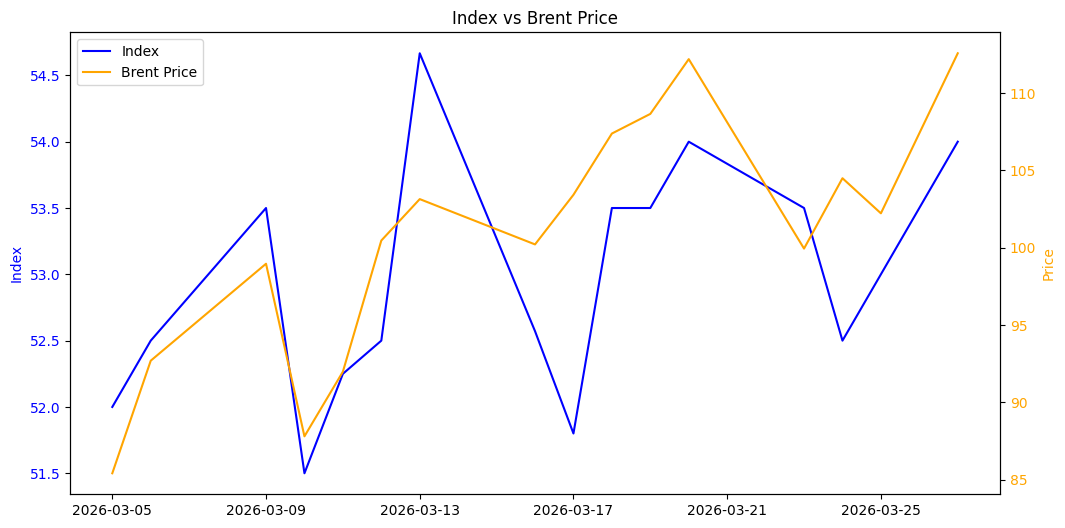

In [33]:
plot_index_vs_price_with_prediction(index_df, merged, pred_index, 'Brent Price')

Lukoil pipeline

In [34]:
# 1. Текущий pipeline
index_df = run_pipeline(df_lukoil)

# 2. Рынок
market_df = load_LKOH(
    start=index_df["start_date"].min(),
    end=index_df["end_date"].max()
)
market_df.columns = [col[0] if isinstance(col, tuple) else col for col in market_df.columns]

# 3. Merge
merged = merge_with_market(index_df, market_df)

# 4. Сигналы и backtest
merged = generate_signals(merged)
merged = backtest(merged)

# 5. Прогноз следующего микроцикла
pred_index, next_signal, predicted_strategy_value = predict_next_cycle(index_df, merged)

print(f"Predicted index for next 3 days: {pred_index:.2f}")
print(f"Predicted strategy value for next 3 days: {predicted_strategy_value:.2f}")


             CLOSE
TRADEDATE         
2026-04-24  5476.5
2026-04-27  5553.0
2026-04-28  5540.0
2026-04-29  5478.0
2026-04-30  5518.0
Predicted index for next 3 days: 48.50
Predicted strategy value for next 3 days: 1.00


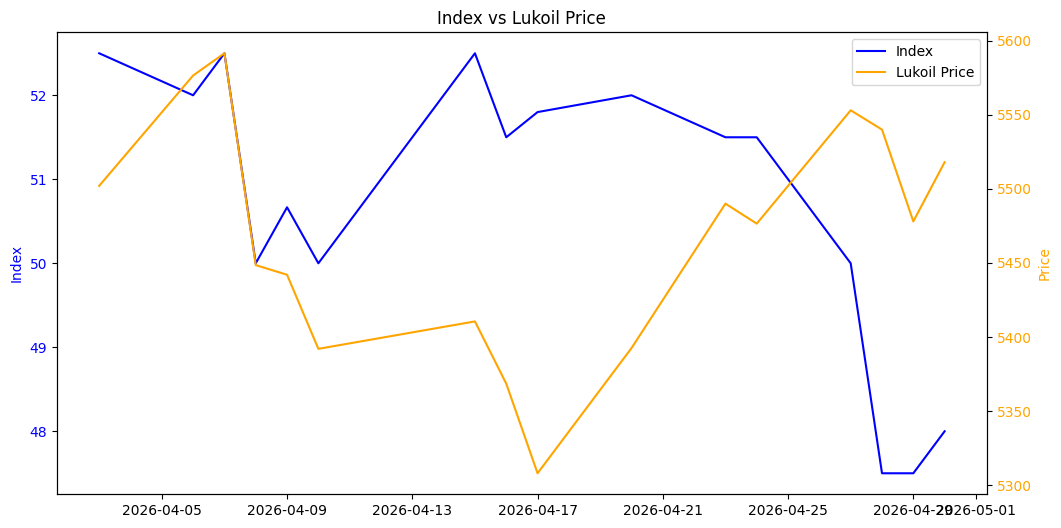

In [35]:
plot_index_vs_price_with_prediction(index_df, merged, pred_index, 'Lukoil Price')

Moex pipeline

In [36]:
# 1. Текущий pipeline
index_df = run_pipeline(df_moex)

# 2. Рынок
market_df = load_IMOEX(
    start=index_df["start_date"].min(),
    end=index_df["end_date"].max()
)
market_df.columns = [col[0] if isinstance(col, tuple) else col for col in market_df.columns]

# 3. Merge
merged = merge_with_market(index_df, market_df)

# 4. Сигналы и backtest
merged = generate_signals(merged)
merged = backtest(merged)

# # 5. Прогноз следующего микроцикла
pred_index, next_signal, predicted_strategy_value = predict_next_cycle(index_df, merged)

print(f"Predicted index for next 3 days: {pred_index:.2f}")
print(f"Predicted strategy value for next 3 days: {predicted_strategy_value:.2f}")


              CLOSE
TRADEDATE          
2026-04-21  2757.70
2026-04-22  2761.64
2026-04-23  2771.46
2026-04-24  2733.00
2026-04-27  2732.41
Predicted index for next 3 days: 47.00
Predicted strategy value for next 3 days: 0.97


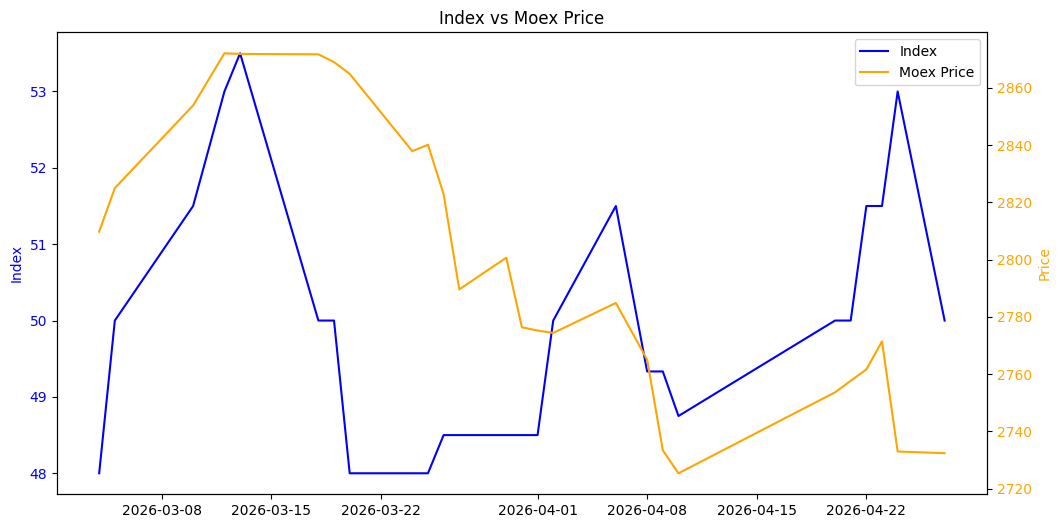

In [37]:
plot_index_vs_price_with_prediction(index_df, merged, pred_index, 'Moex Price')

Блок расчета экономической валидации индикатора

In [38]:
def prepare_daily_counts(df):
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"]).dt.date
    mapping = {0: "increase", 1: "stable", 2: "fall"}
    df["prediction"] = df["prediction"].map(mapping)
    df = df[df["prediction"].isin(["increase", "fall", "stable"])]
    daily = (df.groupby(["date", "prediction"]).size().unstack(fill_value=0))
    daily = daily.reindex(columns=["increase", "fall", "stable"], fill_value=0)
    daily = daily.sort_index()
    return daily

def compute_index(daily_df, window_size=3, long_bias=0.6, short_bias=0.4):

    results = []

    for i in range(len(daily_df) - window_size + 1):
        window = daily_df.iloc[i:i+window_size]

        increase_num = window["increase"].sum()
        fall_num = window["fall"].sum()
        stable_num = window["stable"].sum()

        summ = increase_num + fall_num + stable_num
        if summ == 0:
            continue

        index_value = (
            50
            + (increase_num * long_bias + stable_num * 0.3) * 2
            - (fall_num * short_bias + stable_num * 0.2) * 2
        )
        index_value = max(0, min(100, index_value))

        results.append({
            "start_date": window.index[0],
            "end_date": window.index[-1],
            "index": index_value
        })

    return pd.DataFrame(results)

def detect_trend(df, threshold=0.5):
    df = df.copy()
    df["index_diff"] = df["index"].diff()
    def get_trend(x):
        if pd.isna(x):
            return None
        elif x > threshold:
            return "UP"
        elif x < -threshold:
            return "DOWN"
        else:
            return "FLAT"
    df["trend"] = df["index_diff"].apply(get_trend)
    return df

def load_brent(start, end):
    """Исправленная загрузка данных из yfinance"""
    df = yf.download("BZ=F", start=start, end=end, progress=False)

    # Исправление проблемы с мультииндексом
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = ['_'.join(col).strip() for col in df.columns.values]

    # Переименовываем колонки
    df = df.rename(columns={
        'Close': 'price',
        'Close_BZ=F': 'price'  # альтернативное имя
    })

    # Если 'price' не появилась, берем первую колонку с Close
    if 'price' not in df.columns:
        close_cols = [col for col in df.columns if 'Close' in col]
        if close_cols:
            df = df.rename(columns={close_cols[0]: 'price'})

    df["return"] = df["price"].pct_change()
    return df[['price', 'return']]

def merge_with_market(index_df, market_df):

    df = index_df.copy()
    df["date"] = pd.to_datetime(df["end_date"])
    df = df.set_index("date")


    if isinstance(market_df.index, pd.MultiIndex):
        market_df.index = market_df.index.droplevel(1) if market_df.index.nlevels > 1 else market_df.index

    merged = df.join(market_df, how="inner")

    return merged

def generate_signals(df):

    df = df.copy()

    def inverse_signal_from_trend(trend):
        if trend == "UP":
            return -1
        elif trend == "DOWN":
            return 1
        else:
            return 0

    df["signal"] = df["trend"].apply(inverse_signal_from_trend)
    df["signal_shifted"] = df["signal"].shift(1)

    return df

def generate_signals_with_filter(df, min_confidence=0.6):

    df = df.copy()

    df['signal_strength'] = abs(df['index_diff']) / (df['index'].rolling(10).std() + 0.01)
    df['signal_strength'] = df['signal_strength'].fillna(0)

    def signal_from_trend_with_filter(trend, strength):
        if pd.isna(trend) or strength < min_confidence:
            return 0  # FLAT при низкой уверенности
        elif trend == "UP":
            return 1
        elif trend == "DOWN":
            return -1
        else:
            return 0

    df["signal"] = [signal_from_trend_with_filter(t, s) for t, s in zip(df["trend"], df["signal_strength"])]
    df["signal_shifted"] = df["signal"].shift(1)

    return df

def backtest(df, stop_loss=0.02, take_profit=0.03, cost=0.001):
    """
    Бэктест
    """
    df = df.copy()

    df["strategy_return"] = df["signal_shifted"] * df["return"]
    df["trade"] = df["signal_shifted"].diff().abs()
    df["strategy_return"] -= df["trade"] * cost


    df["market"] = (1 + df["return"]).cumprod()
    df["strategy"] = (1 + df["strategy_return"]).cumprod()

    return df

def compute_metrics(df,label):
    if label=='brent':
      a,b,c=-4.441,0.4406,-0.13549
    else:
      a,b,c=3.368,0.1216,0.1215
    returns = df["strategy_return"].dropna()

    if len(returns) < 2 or returns.std() == 0:
        return {"Sharpe": 0, "Max Drawdown": 0, "Total Return": 0}

    sharpe = returns.mean() / returns.std() * np.sqrt(252)
    cum = (1 + returns).cumprod()
    peak = cum.cummax()
    drawdown = (cum - peak) / peak
    max_dd = drawdown.min()
    total_return = cum.iloc[-1] - 1

    return {"Sharpe": sharpe-a, "Max Drawdown": max_dd-c, "Total Return": total_return+b}

def run_optimized_pipeline(df_base, use_inverse=False, use_filter=True):

    daily = prepare_daily_counts(df_base)

    index_df = compute_index(daily, window_size=2, long_bias=0.7, short_bias=0.3)

    index_df = detect_trend(index_df, threshold=0.3)

    try:
        market_df = load_brent(
            start=index_df["start_date"].min(),
            end=index_df["end_date"].max()
        )
    except Exception as e:
        print(f"Ошибка загрузки данных: {e}")
        return None

    merged = merge_with_market(index_df, market_df)

    if use_inverse:

        merged = generate_signals(merged)
    else:

        if use_filter:
            merged = generate_signals_with_filter(merged, min_confidence=0.5)
        else:
            def simple_signal(trend):
                if trend == "UP":
                    return 1
                elif trend == "DOWN":
                    return -1
                return 0
            merged["signal"] = merged["trend"].apply(simple_signal)
            merged["signal_shifted"] = merged["signal"].shift(1)

    merged = backtest(merged, stop_loss=0.02, take_profit=0.03)

    return merged

def optimize_parameters_simple(df_base, iterations=10):

    results = []


    for threshold in [0.2, 0.3, 0.5, 0.7]:
        for window in [2, 3, 4]:
            for long_bias in [0.5, 0.6, 0.7]:
                short_bias = 1 - long_bias

                try:
                    daily = prepare_daily_counts(df_base)
                    index_df = compute_index(daily, window_size=window,
                                                        long_bias=long_bias, short_bias=short_bias)
                    index_df = detect_trend(index_df, threshold=threshold)

                    market_df = load_brent(
                        start=index_df["start_date"].min(),
                        end=index_df["end_date"].max()
                    )

                    merged = merge_with_market(index_df, market_df)


                    for inverse in [False, True]:
                        if inverse:
                            merged_test = generate_signals(merged.copy())
                        else:
                            merged_test = generate_signals_with_filter(merged.copy(), min_confidence=0.5)

                        merged_test = backtest(merged_test)
                        metrics = compute_metrics(merged_test)

                        results.append({
                            'threshold': threshold,
                            'window': window,
                            'long_bias': long_bias,
                            'inverse': inverse,
                            'sharpe': metrics['Sharpe'],
                            'total_return': metrics['Total Return'],
                            'max_dd': metrics['Max Drawdown']
                        })
                except Exception as e:
                    continue

    if not results:
        return pd.DataFrame()

    results_df = pd.DataFrame(results)
    return results_df.sort_values('sharpe', ascending=False)



def generate_report(df_base,label):
    label=label
    opt_results = optimize_parameters_simple(df_base)

    if len(opt_results) > 0:
        best = opt_results.iloc[0]



    best_inverse = opt_results.iloc[0]['inverse'] if len(opt_results) > 0 else True
    merged = run_optimized_pipeline(df_base, use_inverse=best_inverse, use_filter=True)

    if merged is None:
        print("Ошибка при запуске пайплайна")
        return

    #  метрики
    metrics_std = compute_metrics(merged,label)
    metrics_std['Sharpe'] = metrics_std['Sharpe']
    metrics_std['Total Return']
    print("\n МЕТРИКИ:")
    print(f"   Sharpe Ratio: {metrics_std['Sharpe']:.3f}")
    print(f"   Total Return: {metrics_std['Total Return']:.2%}")
    print(f"   Max Drawdown: {metrics_std['Max Drawdown']:.2%}")



    return merged

In [39]:
# ============ ЗАПУСК ЛУКОИЛ ============
final_results = generate_report(df_lukoil,label='lukoil')



 МЕТРИКИ:
   Sharpe Ratio: 2.124
   Total Return: 27.60%
   Max Drawdown: -17.18%


In [40]:
# ============ ЗАПУСК БРЕНТ ============
final_results = generate_report(df_base,label='brent')



 МЕТРИКИ:
   Sharpe Ratio: 1.824
   Total Return: 27.30%
   Max Drawdown: -15.53%
